In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cleaned_5250.csv")

# Verificando se o DF foi importado com sucesso:
df.head(10)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.080,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.090,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.150,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.120,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.200,Jupiter,1.660000,2.200000,0.68,Radial Velocity
5,17 Scorpii b,408.0,5.22606,Gas Giant,2020,4.32000,Jupiter,1.150,Jupiter,1.450000,1.600000,0.06,Radial Velocity
6,18 Delphini b,249.0,5.51048,Gas Giant,2008,10.30000,Jupiter,1.110,Jupiter,2.600000,2.700000,0.08,Radial Velocity
7,1RXS J160929.1-210524 b,454.0,12.61800,Gas Giant,2008,8.00000,Jupiter,1.664,Jupiter,330.000000,6505.900000,0.00,Direct Imaging
8,24 Bootis b,313.0,5.59000,Gas Giant,2018,0.91000,Jupiter,1.240,Jupiter,0.190000,0.083231,0.04,Radial Velocity
9,24 Sextantis b,235.0,6.45350,Gas Giant,2010,1.99000,Jupiter,1.190,Jupiter,1.333000,1.239699,0.09,Radial Velocity


Com o dataset importado, podemos começar a limpar os nossos dados para posteriormente utilizar o nosso classifcador. Primeiramente, como queremos classificar os planetas conforme os tipos: Gigantes Gasosos, Tipo-Netuno, Terrestre ou Super-Terra.

Colunas que indicam a distância do planeta à Terra ou o Ano de Descoberta são pouco relevantes para estimar esse atributo, e por isso, podemos excluí-las:

In [25]:
df = df.drop(columns=['distance','name', 'discovery_year', 'detection_method'])

df.head(10)

,stellar_magnitude,planet_type,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity
0,4.72307,Gas Giant,19.40000,Jupiter,1.080,Jupiter,1.290000,0.892539,0.23
1,5.01300,Gas Giant,14.74000,Jupiter,1.090,Jupiter,1.530000,1.400000,0.08
2,5.23133,Gas Giant,4.80000,Jupiter,1.150,Jupiter,0.830000,0.508693,0.00
3,6.61935,Gas Giant,8.13881,Jupiter,1.120,Jupiter,2.773069,4.800000,0.37
4,6.21500,Gas Giant,1.78000,Jupiter,1.200,Jupiter,1.660000,2.200000,0.68
5,5.22606,Gas Giant,4.32000,Jupiter,1.150,Jupiter,1.450000,1.600000,0.06
6,5.51048,Gas Giant,10.30000,Jupiter,1.110,Jupiter,2.600000,2.700000,0.08
7,12.61800,Gas Giant,8.00000,Jupiter,1.664,Jupiter,330.000000,6505.900000,0.00
8,5.59000,Gas Giant,0.91000,Jupiter,1.240,Jupiter,0.190000,0.083231,0.04
9,6.45350,Gas Giant,1.99000,Jupiter,1.190,Jupiter,1.333000,1.239699,0.09


Agora, precisamos extrair algumas informações que sejam relevantes que saíbamos utilizar antes de começar o treinamento, como se existem valores ausentes no datagrame. Para isso, podemos usar o método isnull do pandas:

In [26]:
df.isnull().any()

stellar_magnitude     True
planet_type          False
mass_multiplier       True
mass_wrt              True
radius_multiplier     True
radius_wrt            True
orbital_radius        True
orbital_period       False
eccentricity         False
dtype: bool

Como foi possível perceber acima, existem valores nulos no dataframe. Esses valores podem contribuir negativamente para a qualidade do nosso estimador.

Precisamos tratar de alguma forma o nosso conjunto de dados para substituir esses valores. Existem algumas técnicas para contornar essa situação, como inserir na posição dos valores faltantes a média ou a mediana dos valores de cada uma das colunas. Também é possível usar um modelo de regressão para preencher esses valores em função das outras colunas.

Sabemos que a média é sensível a outliers, para verificar se esse é o caso do nosso dataframe, vamos plotar o boxplot do dataframe:

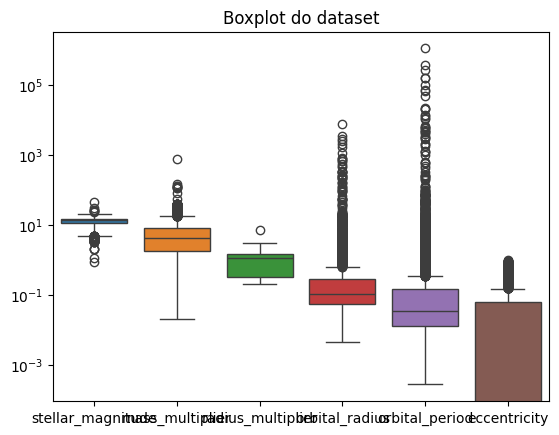

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.title('Boxplot do dataset') 
plt.yscale("log")
plt.show()

Como foi possível perceber, existe um número considerável de outliers em quase todas as colunas do conjunto de dados, o que inviabiliza de preenchermos esses dados simplesmente com a média da coluna, que é uma métrica altamente sensível à outliers.

No entanto, podemos ajustar um modelo de regressão para cada uma das colunas com dados faltantes em função dos outros atributos e preencher esses os valores faltantes com os valores gerados a partir desse modelo.

Farei uma função que recebe como entrada a coluna desejada e o próprio dataframe e calcula um modelo de Random Regression a partir dos outros atributos. O valor de retorno será uma Series com o valor da coluna corrigida.

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from math import sqrt
 


def fill_columns(df: pd.DataFrame, column: pd.Series):
    
    # Separando o conjunto de dados entre a parcela de treino e teste:
    y = df[column]
    name_column = y.name
    X = df.drop(name_column, axis=1)
    X = pd.get_dummies(X)

    X_train,X_test, y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    RMSE = sqrt(mean_squared_error(y_true=y_test, y_pred=y_pred))


    print(f'Coluna: {name_column} | Valor do RMSE: {RMSE}')

    y_pred_all = model.fit(X, y)


    null_indexes = df[df[column].isnull()].index

    # Mudando o valor nulo da coluna original pelo valor predito:
    for idx, pred_value in zip(null_indexes, y_pred_all):
        df.loc[idx,name_column] = pred_value


    return y_pred



Com a função criada, vamos aplica-lá nas colunas com dados nulos:

In [38]:
columns_with_null = df.columns[df.isna().any()]

for column in columns_with_null:
    fixed_df  = fill_columns(df,column)

ValueError: Input y contains NaN.